# TP N°1 Rodrigo Mesa Marchi (a2016)

# TinyGPT

**Author: Abraham R.**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Downloading Dataset

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

#text = text[:300_000]  # Using 100k characters for speedup
#print(text)

# Character-based encoding

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])
data = torch.tensor(encode(text), dtype=torch.long)

# Train/test split
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

# Dataloaders

In [5]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [19]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 4096
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 4096, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 65, 'bias': True, 'ff_class': None, 'moe': None}


In [20]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8,
                        )

In [21]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [23]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [24]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [25]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [26]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
model = torch.compile(m)

In [27]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 10

# Training

In [28]:
# Trainer instance
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):  
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/245 [00:00<?, ?it/s]/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje_2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:2772: UserWarning: NVIDIA GeForce RTX 2060 SUPER does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje_2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:2772: UserWarning: NVIDIA GeForce RTX 2060 SUPER does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje_2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:2772: UserWarning: NVIDIA GeForce RTX 2060 SUPER does not support bfloat16 compilation natively, skipping
  warnings.warn(
/home/rodri/Documents/Maestria/proyectos_maestria/procesamiento_lenguaje_2/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:2772: UserWarning: NVIDIA GeForc

Epoch 1 training loss: 2.0934


val_loss 2.09237: 100%|██████████| 27/27 [00:01<00:00, 22.25it/s]


Epoch 1 validation loss: 2.0612


loss 1.90670: 100%|██████████| 245/245 [01:01<00:00,  3.98it/s]


...

Epoch 9 validation loss: 1.7938


loss 1.71747: 100%|██████████| 245/245 [01:01<00:00,  3.96it/s]


Epoch 10 training loss: 1.7174


val_loss 1.94676: 100%|██████████| 27/27 [00:01<00:00, 21.82it/s]

Epoch 10 validation loss: 1.7910
Training complete.


### Quick test 

In [29]:
generate("To be", max_new_tokens=100,use_cache=True)

'To being why:\nAnd reak you do dest, is that he comply worthink.\n\nJULIET:\nO now thining have a ven\nthy hig'

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)



# Desarrollo de generate V2

En la siguiente función implementaremos todos los tipos solicitados de generación del siguiente token:
- Greedy
- Temperature
- Top k
- Top P

Esto se buscó realizar en la misma función por dos motivos: generar un código mas compacto, al reutilizar las metodologías comunes de generación a cada uno de los métodos, pero también brindar la posibilidad de combinar las métodologías. Según lo que se vaya eligiendo, se hará uso o no de las distintas técnicas, o combinación de estas. 

Esto se buscó realizar imitando la función generate de hugginface, la cual según la combinación de parámetros utilizados, es el tipo de generación que realiza. A continuación se presentará la función desarrollada, y se irán comentando los puntos principales de esta.

In [64]:
@torch.no_grad()
def generateV2(
    model,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    temperature: float = 1.0,
    top_k: int = 10,
    top_p: float = 0.95,
    use_top_k: bool = False,
    use_top_p: bool = False,
    
)-> Optional[str]:

    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None
        
        logits = logits[:, -1, :]  # (batch_size, vocab_size)

        if temperature is not None and temperature != 1.0:
            logits = logits / temperature # Si se estableció una temperatura, dividir los valores por ella.

        if use_top_k:
            topk_logits, topk_indices = torch.topk(logits, top_k, dim=-1) # Si se estableció un valor de topk, seleccionamos los 
            logits = topk_logits                                          # k logits de mayor valor, haciendo los siguientes pasos con ellos
        else:
            topk_indices = None

        if use_top_p:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1) # Para usar top p, debemos primero obtener las probabilidades acumuladas
            probs = F.softmax(sorted_logits, dim=-1)                                    # Hacemos dos pasos de softmax (el general y el interno de top p)
            cumulative_probs = torch.cumsum(probs, dim=-1)                              # Esto para obtener la probabilidad acumulada, filtrar, y despues de filtrar 
                                                                                        # obtener probabilidades que igualen a 1
            mask = cumulative_probs > top_p
            mask[..., 1:] = mask[..., :-1].clone()
            mask[..., 0] = False

            sorted_logits[mask] = float('-inf')

            logits = torch.zeros_like(logits).scatter(-1, sorted_indices, sorted_logits)



        probs = F.softmax(logits, dim=-1)

        if use_top_k or use_top_p or (temperature is not None and temperature != 1.0):
            next_token = torch.multinomial(probs, num_samples=1)  # (batch_size, 1) # Para cualquiera distinto de greedy, hacemos muestreo ponderado
        else:
            next_token = torch.argmax(probs, dim=-1, keepdim=True)  # (batch_size, 1) # Greedy Decoding

        if use_top_k:
            next_token = torch.gather(topk_indices, -1, next_token) # Si utilizamos top k debemos traducir el indice seleccionado, al indice original del token

        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())


En base a esto, para analizar los resultados, haremos uso de los distintos generadores, verificando su output

Generador original

In [38]:
result_1 = generate("To be", max_new_tokens=100,use_cache=True)
print(result_1)

To be wrom forther? what to and thou kily
The hange
Will: by goght thereith of sham,
Or him when have. Gi


## Greedy Search

In [65]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=1.0)
print(result_2)

To be the shall the see the shall the so the shall the so the shall the so the shall the so the shall the


## Temperature sampling

### T < 1.0

In [ ]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=0.45)
print(result_2)

To be the the son, you that the worth.

LUCIO:
Ay, I will not the with stand and all the sister should ha


### T > 0

In [ ]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=1.55)
print(result_2)

To be'er say?
wismonainie!
Nmecbed hence, courget, vu lectIo-have
fi;
 desirefs; not, God:f', blove.

QU 


### T ~= 0

In [ ]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=0.001)
print(result_2)

To be the shall the see the shall the so the shall the so the shall the so the shall the so the shall the


## topK

In [ ]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=1.0, use_top_k=True)
print(result_2)

To besures. I lay your losse must mischard's blainsty,
Sparge you have be but as for his claving weman me


## Top P

In [ ]:
result_2 = generateV2(model,"To be", max_new_tokens=100,use_cache=True,temperature=1.0, use_top_p=True)
print(result_2)

To becons,
The not bask'd and with art thy king,
This his apparts all were with for with your father:
Cap


# Conclusiones

Al analizar todos los casos podemos denotar las siguientes observaciones.

- La diferencia entre el método generar y generar_v2 radia en la flexibilidad del segundo: uno tiene la posibilidad de modificar de manera significativa los outputs generados, simplemente mediante la modificación de los parámetros de generación. Esto nos permite tener comportamientos bastante diferentes entre las distintas generaciones, sin modificar los pesos del modelo, o reentrenar el mismo.

- La busqueda greedy nos muestra que seleccionar el token con mayor probabilidad no es ideal a la hora de generar textos. Puede observarse que mediante esta técnica, el modelo no genera buenos resultados, entrando en loops de generación donde no puede salir. Con este aspecto, podemos observar de las ventajas implicitas de utilizar algún mecanismo de selección aleatorio

- Temperatura: podemos observar como la temperatura es un parámetro extremadamente útil, ya que podemos modificar la diferencia de los outputs con un único parámetro. Si la temperatura es menor que 1, se incrementará la diferencia en probabilidades entre los tokens con mayor probabilidad, que los que presentan una menor, logrando así resultados mas estables (a costa de pérdida de variabilidad del output). Si colocamos una temperatura mayor que 1, esto vuelve mas similares las probabilidades, aumentando así la variabilidad del resultado final. Esto se refleja en los resultados, una temperatura menor que 1 conduce a lo que parece una escritura mas real, mientras que una temperatura mayor a 1 nos devuelve una escritura menos coherente. Si a su vez colocamos la temperatura muy similar a 0, como vemos, obtenemos resultados muy similares a la busqueda greedy.

- Top-k y top-p: estas configuraciones son de extrema utilidad para reducir el espacio de selección, volviendolo mas acotado sin pérdida aparente de calidad. Podemos segun el criterio utilizado reducir significativamente el número de tokens de los cuales seleccionar, uno mediante un número de tokens, mientras que el otro mediante la selección de probabilidad. Estos a su vez pueden combinarse con el control por temperatura, permitiendo optimizar aún mas la generación, según se requiera.

Es muy improtante mencionar que, si bien los resultados muestran cierta lógica en la generación, distan bastante de buenos resultados. En gran parte esto se debe a la selección del tokenizador utilizado. Una manera en la que creo que podría mejorarse significativamente los resultados, sería mediante tanto un aumento en el tamaño del corpus, como también en la modificación del tokenizador utilizado.

## Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [ ]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        ) ## Example network

    def forward(self, x) -> torch.Tensor:
        return self.net(x) #Agregamos paso forward del expert


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        return self.proj(x)

Utilizamos como guía para la MoELayer: https://apxml.com/posts/how-to-implement-moe-pytorch

In [ ]:
class MoELayer(nn.Module):
    """
    Mixture of experts FeedForward Layer
    """

    def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, x: torch.Tensor) -> torch.Tensor:     # Agregamos el paso forward de la layer MOE
        B, T, C = x.shape                                   # B: batch, T: Cantidad de tokens (ventana) , C: embedding

        # Obtener logits de gating
        gate_logits = self.gate(x)                          # Obtenemos un valor de logit por token por experto (para cada batch)
        gate_probs = F.softmax(gate_logits, dim=-1)         # Obtenemos probabilidades por experto por token

         
        topk_vals, topk_idx = torch.topk(                   # Seleccionamos top k expertos    
            gate_probs, self.args.num_experts_per_token, dim=-1
        )                                                   

        outputs = torch.zeros_like(x)

        for k in range(self.args.num_experts_per_token):    # Para cada experto seleccionado
            expert_idx = topk_idx[..., k]                   
            expert_weight = topk_vals[..., k]               

            flat_x = x.reshape(B*T, C)

                                                            # Ejecutamos cada experto, mediante un mask
            for e_id, expert in enumerate(self.experts):
                mask = (expert_idx.reshape(B*T) == e_id)
                if mask.any():
                    out = expert(flat_x[mask])
                    outputs.reshape(B*T, C)[mask] += out * expert_weight.reshape(B*T)[mask][:, None]

        return outputs

In [51]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(  
            experts=[Expert(config) for _ in range(config.moe.num_experts)],
            gate=Gate(config),
            moe_args=config.moe
        )

    def forward(self, x):
        return self.moe(x)

## Adding MoE to Config

In [56]:
config.ff_class = MoEFFN
config.moe = MoEArgs(num_experts=4, num_experts_per_token=2)

# Training TinyGPT-MoE


In [ ]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m_moe) #Cambiamos código aquí (antes compilaba el model original)

In [58]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 5

Entrenamos para 5 epochs y 4 expertos

In [59]:
# Trainer instance
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs): 
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

loss 2.04550: 100%|██████████| 245/245 [01:36<00:00,  2.54it/s]


Epoch 1 training loss: 2.0342


val_loss 2.08108: 100%|██████████| 27/27 [00:02<00:00, 11.26it/s]


Epoch 1 validation loss: 2.0353


loss 1.80406: 100%|██████████| 245/245 [01:36<00:00,  2.54it/s]


...

Epoch 4 validation loss: 1.7550


loss 1.65352: 100%|██████████| 245/245 [01:35<00:00,  2.57it/s]


Epoch 5 training loss: 1.6537


val_loss 1.95365: 100%|██████████| 27/27 [00:02<00:00, 11.26it/s]

Epoch 5 validation loss: 1.7354
Training complete.


En primer lugar, como era de esperarse, el entrenamiento es un poco mas lento que el entrenamiento original, aproximadamente para 4 expertos es el doble por epoch que el TinyGPT original. Si analizamos los resultados de la salida, tendremos:

In [67]:
result_2 = generateV2(model_moe,"To be", max_new_tokens=100,use_cache=True,temperature=0.7, use_top_p=True)
print(result_2)

To be heave to be the words,
The pray the man the good upon you send of this strunks of so such of the wi


Podemos ver que para el uso de una temperatura menor a 1 y el uso de top p, las respuesta comienza a tener cierto grado de sentido, si bien todavía se aleja de un modelo de LLM. Esta parece mas estable, completando palabras completas. A continuación, analizaremos los mecanismos de atención, tanto para el modelo origianal como para el modelo con expertos:

## Visualización de atención

In [60]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


## Modelo TinyGPT

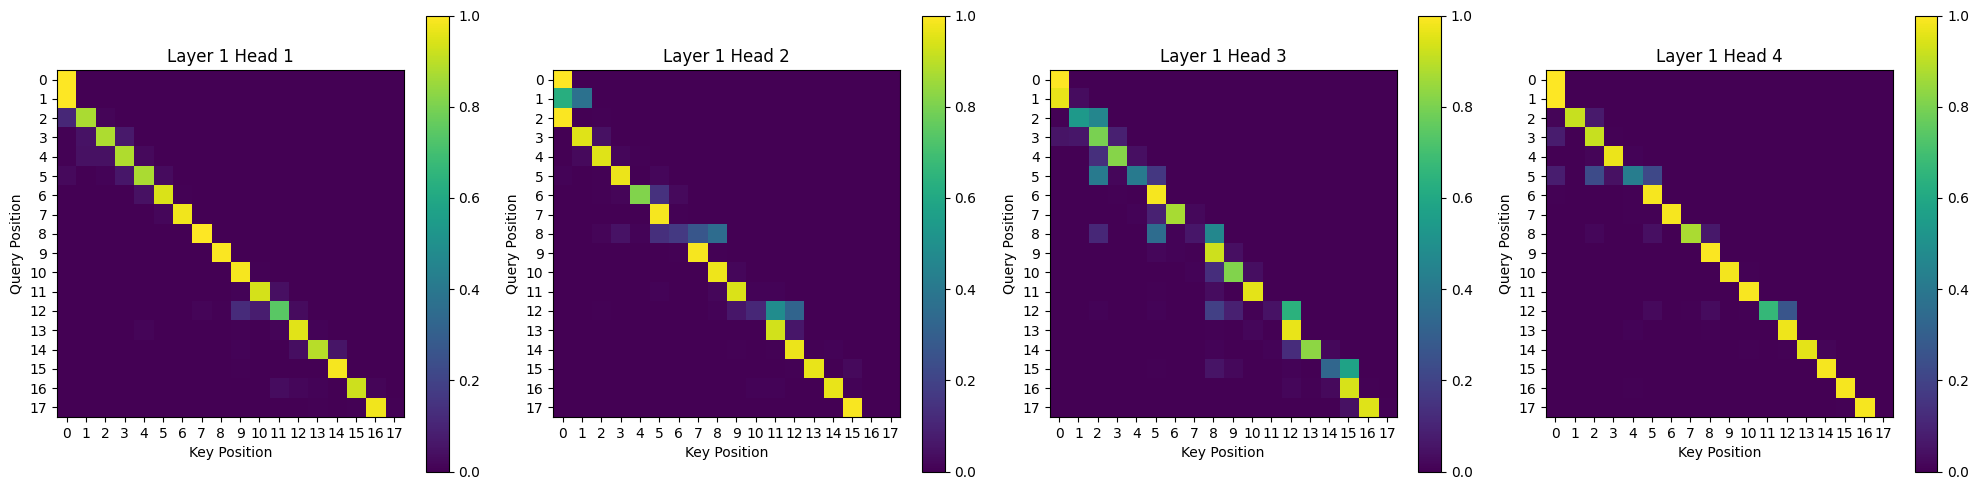

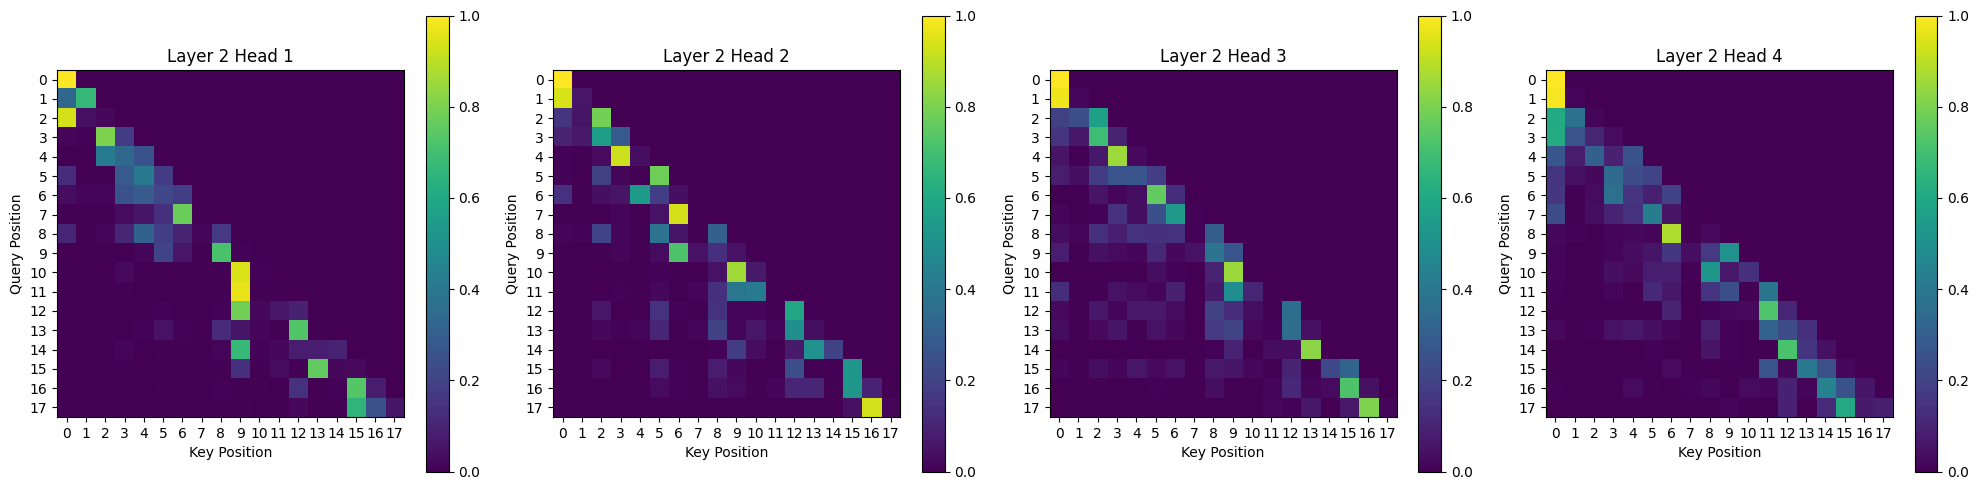

In [61]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

## Modelo TinyGPT MOE

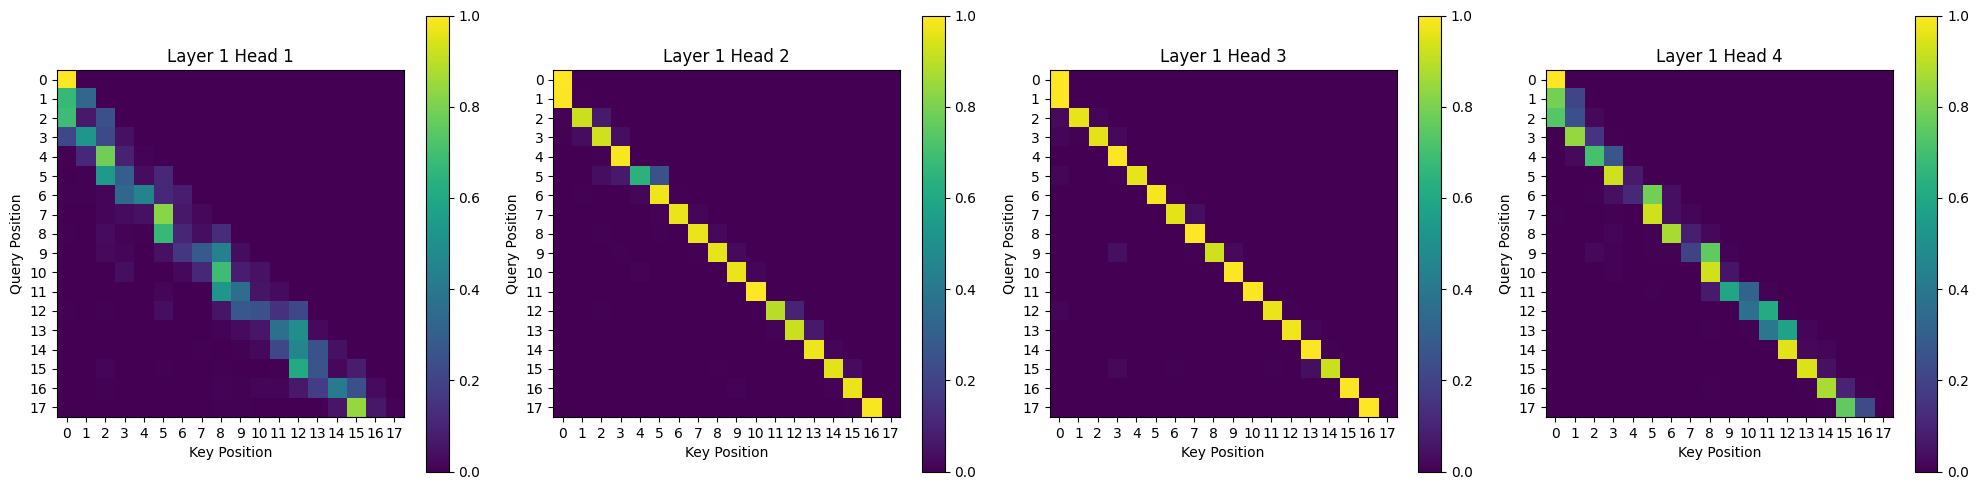

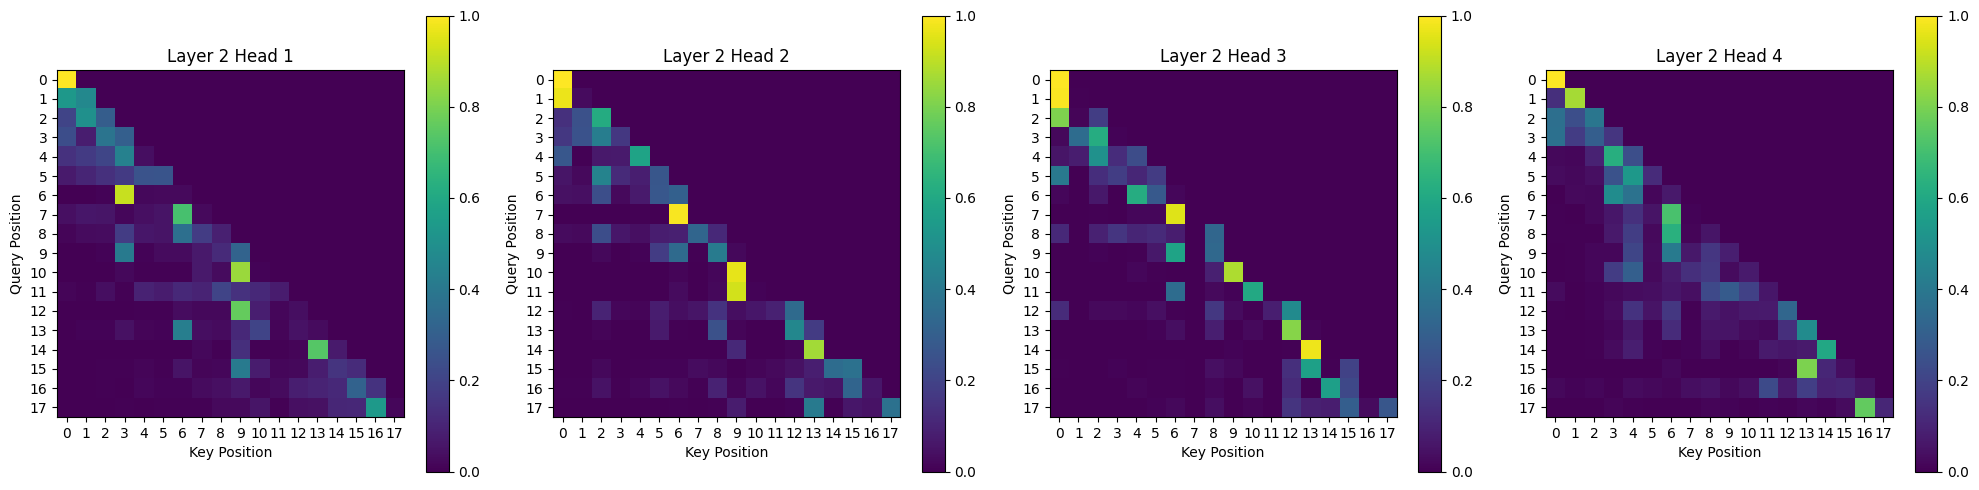

In [62]:
visualize_attention(model=model_moe, prompt=prompt)

Podemos ver en ambos casos como para la primer capa, los contextos de atención son mucho mas acotados que en la segunda capa. Para algunos tokens, apenas logramos activacion de otras posiciones en los distintos heads de las capa numero 1. Ahora bien, ya en la segunda capa emepzamos a ver como esto cambia drasticamente, y un número mayor de posiciones se activan para ciertos tokens. con esto vemos como el modelo "se empieza a fijar en aspectos de la oracion" para ir contruyendo el significado, y predecir el siguiente token.

# Conclusiones

En este práctico pudimos ir analizando las distintas partes que componen a una versión simplificada de un modelo GPT. Mediante la utilización de un pequeño corpus, pudimos entrenar y evaluar el desempeño del entrenamiento en cuestión. A su vez, se pudieron desarrollar y verificar distintos mecanismos para la generación de tokens, con la cual encontramos que el desempaño del modelo podría mejorar significativamente si se utilizase un corpus mayor, como también un tokenizador un poco mas avanzado. 

Otro aspecto importante es que el modelo prsenta una flexibilidad de generación elevada, la cual se ve ligada a als distintas metodologías de generación. Mediante la variación de los parámetros, podremos volerlo mas "creativo" generando texto, o mas conservador. Según sea la funcionalidad del modelo, podremos ajustarlo según se requiera.

Con la incorporación y configuracion de los MOE, comprendí como los diferentes modelos hacen uso de esta técnica, y pude analizar su desempeño: observando como la utilización de esta conduce a una generación de texto un poco mas robusta, sin modificar ni el tamaño del corpus, y con un número reducido de epochs de entrenamiento.